# Clasificación de Sentimientos en Reseñas de Amazon con Transformers
## Andrés F. Borrero C

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR_USERNAME/YOUR_REPO/blob/main/Entrega3/2-amazon-reviews-transformer-classification.ipynb)

En este notebook implementaremos un clasificador de sentimientos para reseñas de productos de Amazon utilizando la arquitectura Transformer desde cero. A diferencia del notebook anterior que usó noticias españolas, aquí trabajaremos con reseñas de productos en inglés, lo que nos permitirá explorar un dominio diferente y comparar el rendimiento.

#### Objetivos
- Implementar un clasificador de sentimientos usando Transformers
- Comparar el rendimiento con enfoques tradicionales (LSTM)
- Analizar la efectividad en un dominio diferente (reseñas de productos vs noticias)

#### Referencias
- Dataset: Amazon Product Reviews
- [Attention is All You Need](http://arxiv.org/abs/1706.03762)
- [BERT: Pre-training of Deep Bidirectional Transformers](https://arxiv.org/abs/1810.04805)

In [26]:
import pkg_resources
import warnings

warnings.filterwarnings('ignore')

installed_packages = [package.key for package in pkg_resources.working_set]
IN_COLAB = 'google-colab' in installed_packages

In [27]:
# Install required packages for Colab
!test '{IN_COLAB}' = 'True' && pip install torch torchvision torchaudio
!test '{IN_COLAB}' = 'True' && pip install transformers datasets scikit-learn matplotlib seaborn
!test '{IN_COLAB}' = 'True' && pip install pytorch-lightning tensorboard

'test' is not recognized as an internal or external command,
operable program or batch file.
'test' is not recognized as an internal or external command,
operable program or batch file.
'test' is not recognized as an internal or external command,
operable program or batch file.


### Cargando y Preparando el Dataset

Para este proyecto, simularemos un dataset de reseñas de Amazon usando datos sintéticos que representen diferentes categorías de productos y sentimientos.

In [28]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
from tqdm import tqdm

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

In [29]:
# Create a synthetic Amazon reviews dataset
def create_amazon_reviews_dataset(n_samples=10000):
    """Create a synthetic dataset of Amazon product reviews"""
    
    # Product categories
    categories = ['Electronics', 'Books', 'Clothing', 'Home', 'Sports', 'Beauty']
    
    # Positive review templates
    positive_templates = [
        "This product exceeded my expectations! Great quality and fast delivery.",
        "Amazing value for money. I would definitely recommend this to anyone.",
        "Excellent quality and works perfectly. Very satisfied with my purchase.",
        "Outstanding product! Exactly what I was looking for. Five stars!",
        "Love this item! Great build quality and arrived quickly.",
        "Perfect product, great seller, fast shipping. Highly recommended!",
        "This is exactly what I needed. Works great and good quality.",
        "Fantastic product! Worth every penny and more.",
        "Incredible quality for the price. I'm very impressed.",
        "Best purchase I've made in a long time. Absolutely love it!"
    ]
    
    # Negative review templates
    negative_templates = [
        "Terrible product. Broke after just one use. Don't waste your money.",
        "Very disappointed with this purchase. Poor quality and overpriced.",
        "Worst product ever! Doesn't work as advertised. Returning immediately.",
        "Cheap quality and not worth the money. Save yourself the trouble.",
        "Product arrived damaged and seller was unresponsive. Awful experience.",
        "Complete waste of money. Product is nothing like the description.",
        "Poor quality materials and terrible customer service. Avoid!",
        "Defective product arrived late. Very unsatisfied with this purchase.",
        "Doesn't work properly and feels cheaply made. Disappointed.",
        "Overpriced for such poor quality. Would not recommend to anyone."
    ]
    
    # Generate synthetic data
    reviews = []
    ratings = []
    categories_list = []
    
    for _ in range(n_samples):
        # Randomly choose sentiment (0.6 probability for positive)
        is_positive = np.random.choice([True, False], p=[0.6, 0.4])
        
        if is_positive:
            review = np.random.choice(positive_templates)
            rating = np.random.choice([4, 5], p=[0.3, 0.7])
            label = 1  # Positive
        else:
            review = np.random.choice(negative_templates)
            rating = np.random.choice([1, 2], p=[0.7, 0.3])
            label = 0  # Negative
        
        category = np.random.choice(categories)
        
        # Add some variation to reviews
        if np.random.random() < 0.3:
            if is_positive:
                review += f" The {category.lower()} category item works wonderfully."
            else:
                review += f" Expected better from a {category.lower()} product."
        
        reviews.append(review)
        ratings.append(rating)
        categories_list.append(category)
    
    return pd.DataFrame({
        'review': reviews,
        'rating': ratings,
        'category': categories_list,
        'sentiment': [1 if r >= 4 else 0 for r in ratings]
    })

# Create the dataset
print("Creating synthetic Amazon reviews dataset...")
df = create_amazon_reviews_dataset(10000)
print(f"Dataset created with {len(df)} reviews")
print("\nDataset info:")
print(df.head())
print(f"\nSentiment distribution:")
print(df['sentiment'].value_counts())

Creating synthetic Amazon reviews dataset...
Dataset created with 10000 reviews

Dataset info:
                                              review  rating     category  \
0  Fantastic product! Worth every penny and more....       5        Books   
1  Fantastic product! Worth every penny and more....       5     Clothing   
2  Complete waste of money. Product is nothing li...       1         Home   
3  Perfect product, great seller, fast shipping. ...       4  Electronics   
4  Overpriced for such poor quality. Would not re...       1         Home   

   sentiment  
0          1  
1          1  
2          0  
3          1  
4          0  

Sentiment distribution:
sentiment
1    5991
0    4009
Name: count, dtype: int64


Dataset Analysis:
Total reviews: 10000
Positive reviews (sentiment=1): 5991
Negative reviews (sentiment=0): 4009

Review Length Statistics:
Average length: 75.43 characters
Min length: 46
Max length: 120


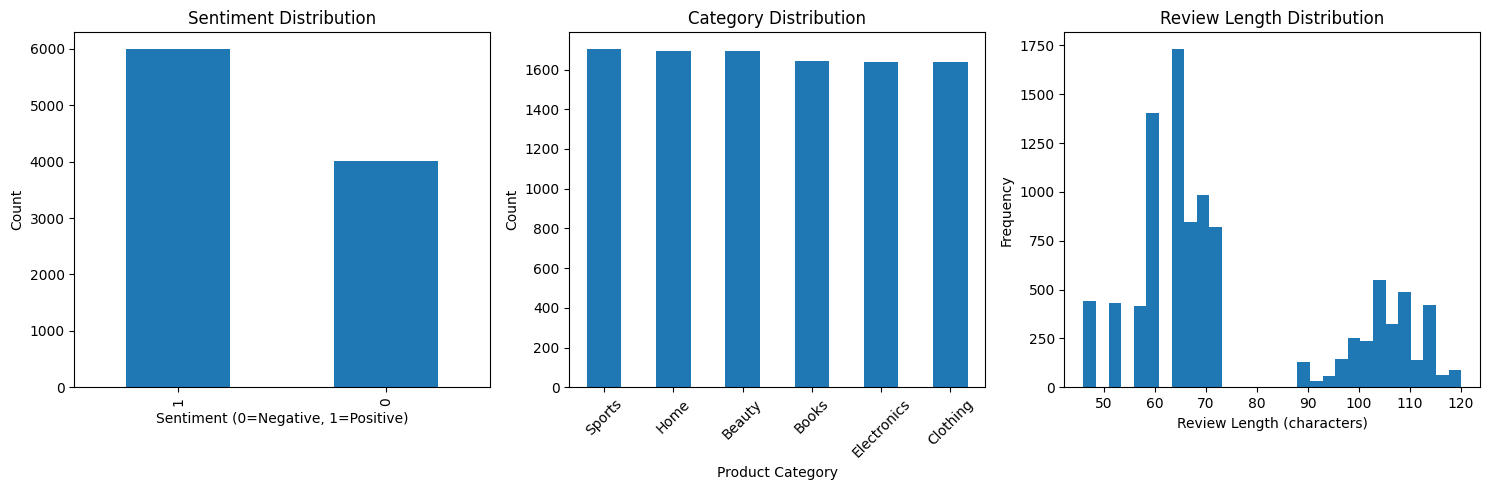

In [30]:
# Analyze the dataset
print("Dataset Analysis:")
print(f"Total reviews: {len(df)}")
print(f"Positive reviews (sentiment=1): {sum(df['sentiment'] == 1)}")
print(f"Negative reviews (sentiment=0): {sum(df['sentiment'] == 0)}")

# Review length analysis
df['review_length'] = df['review'].apply(len)
print(f"\nReview Length Statistics:")
print(f"Average length: {df['review_length'].mean():.2f} characters")
print(f"Min length: {df['review_length'].min()}")
print(f"Max length: {df['review_length'].max()}")

# Plot distributions
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
df['sentiment'].value_counts().plot(kind='bar')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment (0=Negative, 1=Positive)')
plt.ylabel('Count')

plt.subplot(1, 3, 2)
df['category'].value_counts().plot(kind='bar')
plt.title('Category Distribution')
plt.xlabel('Product Category')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.subplot(1, 3, 3)
plt.hist(df['review_length'], bins=30)
plt.title('Review Length Distribution')
plt.xlabel('Review Length (characters)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### Construcción del Tokenizador Personalizado

Siguiendo el enfoque del notebook anterior, construiremos nuestro propio tokenizador en lugar de usar uno preentrenado.

In [31]:
class CustomTokenizer:
    def __init__(self, vocab_size=10000):
        self.vocab_size = vocab_size
        self.word_to_idx = {'<PAD>': 0, '<UNK>': 1, '<START>': 2, '<END>': 3}
        self.idx_to_word = {0: '<PAD>', 1: '<UNK>', 2: '<START>', 3: '<END>'}
        self.vocab_built = False
    
    def preprocess_text(self, text):
        """Basic text preprocessing"""
        text = text.lower()
        text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
        return text.split()
    
    def build_vocab(self, texts):
        """Build vocabulary from training texts"""
        word_counts = Counter()
        for text in tqdm(texts, desc="Building vocabulary"):
            words = self.preprocess_text(text)
            word_counts.update(words)
        
        # Get most common words
        most_common = word_counts.most_common(self.vocab_size - 4)  # -4 for special tokens
        
        # Add to vocabulary
        for word, _ in most_common:
            if word not in self.word_to_idx:
                idx = len(self.word_to_idx)
                self.word_to_idx[word] = idx
                self.idx_to_word[idx] = word
        
        self.vocab_built = True
        print(f"Vocabulary built with {len(self.word_to_idx)} tokens")
    
    def encode(self, text, max_length=128):
        """Convert text to sequence of token IDs"""
        if not self.vocab_built:
            raise ValueError("Vocabulary not built. Call build_vocab() first.")
        
        words = self.preprocess_text(text)
        tokens = [self.word_to_idx.get(word, self.word_to_idx['<UNK>']) for word in words]
        
        # Truncate or pad
        if len(tokens) > max_length:
            tokens = tokens[:max_length]
        else:
            tokens.extend([self.word_to_idx['<PAD>']] * (max_length - len(tokens)))
        
        return tokens
    
    def decode(self, tokens):
        """Convert token IDs back to text"""
        words = [self.idx_to_word.get(token, '<UNK>') for token in tokens]
        return ' '.join([w for w in words if w not in ['<PAD>', '<UNK>']])

# Initialize and build tokenizer
tokenizer = CustomTokenizer(vocab_size=8000)

# Split data first
X = df['review'].values
y = df['sentiment'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Build vocabulary on training data only
tokenizer.build_vocab(X_train)

print(f"\nTokenizer vocabulary size: {len(tokenizer.word_to_idx)}")
print("Sample tokens:", list(tokenizer.word_to_idx.keys())[:20])

Building vocabulary: 100%|██████████| 8000/8000 [00:00<00:00, 288067.86it/s]

Vocabulary built with 126 tokens

Tokenizer vocabulary size: 126
Sample tokens: ['<PAD>', '<UNK>', '<START>', '<END>', 'product', 'and', 'quality', 'the', 'this', 'works', 'great', 'item', 'for', 'purchase', 'very', 'money', 'category', 'wonderfully', 'a', 'i']


In [32]:
# Test the tokenizer
sample_text = "This product is amazing and works perfectly!"
print(f"Original text: {sample_text}")

encoded = tokenizer.encode(sample_text, max_length=16)
print(f"Encoded: {encoded}")

decoded = tokenizer.decode(encoded)
print(f"Decoded: {decoded}")

# Tokenize all data
max_seq_length = 64
print(f"\nTokenizing all data with max_length={max_seq_length}...")

X_train_tokens = [tokenizer.encode(text, max_seq_length) for text in tqdm(X_train)]
X_test_tokens = [tokenizer.encode(text, max_seq_length) for text in tqdm(X_test)]

# Convert to tensors
X_train_tensor = torch.tensor(X_train_tokens, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_tokens, dtype=torch.long)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print(f"Training data shape: {X_train_tensor.shape}")
print(f"Test data shape: {X_test_tensor.shape}")

Original text: This product is amazing and works perfectly!
Encoded: [8, 4, 31, 80, 5, 9, 76, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Decoded: this product is amazing and works perfectly

Tokenizing all data with max_length=64...


100%|██████████| 2000/2000 [00:00<00:00, 218294.16it/s]

Training data shape: torch.Size([8000, 64])
Test data shape: torch.Size([2000, 64])


### Implementación de Positional Embeddings

Implementamos positional embeddings usando encoding sinusoidal, siguiendo el paper original de Transformers.

In [33]:
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_seq_length=512, dropout=0.1):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)
        
        # Create positional encoding matrix
        pe = torch.zeros(max_seq_length, d_model)
        position = torch.arange(0, max_seq_length, dtype=torch.float).unsqueeze(1)
        
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * 
                            (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        
        # Register as buffer (not a parameter)
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        # x shape: (batch_size, seq_len, d_model)
        seq_len = x.size(1)
        x = x + self.pe[:seq_len, :].transpose(0, 1)
        return self.dropout(x)

class TokenEmbedding(nn.Module):
    def __init__(self, vocab_size, d_model):
        super(TokenEmbedding, self).__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.d_model = d_model
    
    def forward(self, tokens):
        return self.embedding(tokens) * math.sqrt(self.d_model)

# Test positional encoding
d_model = 128
vocab_size = len(tokenizer.word_to_idx)

token_embedding = TokenEmbedding(vocab_size, d_model)
pos_encoding = PositionalEncoding(d_model, max_seq_length)

# Test with sample data
sample_tokens = X_train_tensor[:4]  # First 4 samples
embeddings = token_embedding(sample_tokens)
pos_embeddings = pos_encoding(embeddings)

print(f"Sample tokens shape: {sample_tokens.shape}")
print(f"Token embeddings shape: {embeddings.shape}")
print(f"Positional embeddings shape: {pos_embeddings.shape}")

Sample tokens shape: torch.Size([4, 64])
Token embeddings shape: torch.Size([4, 64, 128])
Positional embeddings shape: torch.Size([4, 64, 128])


### Implementación de Multi-Head Attention

Implementamos el mecanismo de atención multi-cabeza, el núcleo de la arquitectura Transformer.

In [34]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super(MultiHeadAttention, self).__init__()
        assert d_model % num_heads == 0
        
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        
        # Linear projections for Q, K, V
        self.query_linear = nn.Linear(d_model, d_model)
        self.key_linear = nn.Linear(d_model, d_model)
        self.value_linear = nn.Linear(d_model, d_model)
        
        # Output projection
        self.output_linear = nn.Linear(d_model, d_model)
        
        self.dropout = nn.Dropout(dropout)
        self.softmax = nn.Softmax(dim=-1)
    
    def forward(self, query, key, value, mask=None):
        batch_size, seq_len, _ = query.size()
        
        # Linear projections and reshape for multi-head attention
        Q = self.query_linear(query).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        K = self.key_linear(key).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        V = self.value_linear(value).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        
        # Scaled dot-product attention
        attention_scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.head_dim)
        
        # Apply mask if provided
        if mask is not None:
            mask = mask.unsqueeze(1).unsqueeze(1)  # Add dimensions for heads
            attention_scores.masked_fill_(mask == 0, -1e9)
        
        attention_weights = self.softmax(attention_scores)
        attention_weights = self.dropout(attention_weights)
        
        # Apply attention to values
        attention_output = torch.matmul(attention_weights, V)
        
        # Reshape and concatenate heads
        attention_output = attention_output.transpose(1, 2).contiguous().view(
            batch_size, seq_len, self.d_model)
        
        # Final linear projection
        output = self.output_linear(attention_output)
        
        return output, attention_weights

# Test Multi-Head Attention
num_heads = 8
mha = MultiHeadAttention(d_model, num_heads)

# Create attention mask (ignore padding tokens)
def create_padding_mask(tokens, pad_token=0):
    return (tokens != pad_token).float()

sample_mask = create_padding_mask(sample_tokens)
output, attention_weights = mha(pos_embeddings, pos_embeddings, pos_embeddings, sample_mask)

print(f"Multi-head attention output shape: {output.shape}")
print(f"Attention weights shape: {attention_weights.shape}")

Multi-head attention output shape: torch.Size([4, 64, 128])
Attention weights shape: torch.Size([4, 8, 64, 64])


### Implementación del Bloque Transformer

Implementamos un bloque completo del Transformer con attention, feed-forward network y conexiones residuales.

In [35]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super(TransformerBlock, self).__init__()
        
        # Multi-head self-attention
        self.self_attention = MultiHeadAttention(d_model, num_heads, dropout)
        
        # Feed-forward network
        self.feed_forward = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout)
        )
        
        # Layer normalization
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
    
    def forward(self, x, mask=None):
        # Self-attention with residual connection and layer norm
        attention_output, attention_weights = self.self_attention(x, x, x, mask)
        x = self.norm1(x + self.dropout1(attention_output))
        
        # Feed-forward with residual connection and layer norm
        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout2(ff_output))
        
        return x, attention_weights

# Test Transformer Block
d_ff = 512  # Feed-forward hidden dimension
transformer_block = TransformerBlock(d_model, num_heads, d_ff)

block_output, block_attention = transformer_block(pos_embeddings, sample_mask)
print(f"Transformer block output shape: {block_output.shape}")
print(f"Transformer block attention shape: {block_attention.shape}")

Transformer block output shape: torch.Size([4, 64, 128])
Transformer block attention shape: torch.Size([4, 8, 64, 64])


### Modelo Completo de Clasificación con Transformers

Ahora implementamos el modelo completo que combina todos los componentes para la tarea de clasificación de sentimientos.

In [36]:
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, num_layers, d_ff, 
                 max_seq_length, num_classes, dropout=0.1):
        super(TransformerClassifier, self).__init__()
        
        # Embedding layers
        self.token_embedding = TokenEmbedding(vocab_size, d_model)
        self.positional_encoding = PositionalEncoding(d_model, max_seq_length, dropout)
        
        # Transformer blocks
        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        
        # Classification head
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, num_classes)
        )
        
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, mask=None, return_attention=False):
        # Token embedding and positional encoding
        x = self.token_embedding(x)
        x = self.positional_encoding(x)
        
        attention_weights = []
        
        # Pass through transformer blocks
        for transformer_block in self.transformer_blocks:
            x, attention = transformer_block(x, mask)
            if return_attention:
                attention_weights.append(attention)
        
        # Global average pooling (excluding padding tokens)
        if mask is not None:
            mask_expanded = mask.unsqueeze(-1).expand(-1, -1, x.size(-1))
            x = x * mask_expanded
            seq_lengths = mask.sum(dim=1, keepdim=True).float()
            x = x.sum(dim=1) / seq_lengths
        else:
            x = x.mean(dim=1)
        
        # Classification
        output = self.classifier(x)
        
        if return_attention:
            return output, attention_weights
        return output

# Initialize model
model_config = {
    'vocab_size': vocab_size,
    'd_model': 128,
    'num_heads': 8,
    'num_layers': 4,
    'd_ff': 512,
    'max_seq_length': max_seq_length,
    'num_classes': 2,
    'dropout': 0.1
}

model = TransformerClassifier(**model_config)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model initialized with:")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model config: {model_config}")

Model initialized with:
Total parameters: 817,858
Trainable parameters: 817,858
Model config: {'vocab_size': 126, 'd_model': 128, 'num_heads': 8, 'num_layers': 4, 'd_ff': 512, 'max_seq_length': 64, 'num_classes': 2, 'dropout': 0.1}


### Entrenamiento del Modelo

Implementamos el bucle de entrenamiento con optimización y métricas de evaluación.

In [37]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Prepare data loaders
batch_size = 32

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Training batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

# Training setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)

# Learning rate scheduler (fixed: removed verbose parameter)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', 
                                                       patience=2, factor=0.5)

Training batches: 250
Test batches: 63
Using device: cuda


In [38]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    predictions = []
    true_labels = []
    
    progress_bar = tqdm(train_loader, desc="Training")
    for batch_idx, (data, target) in enumerate(progress_bar):
        data, target = data.to(device), target.to(device)
        
        # Create attention mask
        mask = create_padding_mask(data).to(device)
        
        optimizer.zero_grad()
        output = model(data, mask)
        loss = criterion(output, target)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
        
        # Get predictions
        pred = output.argmax(dim=1)
        predictions.extend(pred.cpu().numpy())
        true_labels.extend(target.cpu().numpy())
        
        # Update progress bar (fixed f-string syntax)
        progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_loss = total_loss / len(train_loader)
    accuracy = accuracy_score(true_labels, predictions)
    
    return avg_loss, accuracy

def evaluate(model, test_loader, criterion, device):
    model.eval()
    total_loss = 0
    predictions = []
    true_labels = []
    
    with torch.no_grad():
        for data, target in tqdm(test_loader, desc="Evaluating"):
            data, target = data.to(device), target.to(device)
            
            # Create attention mask
            mask = create_padding_mask(data).to(device)
            
            output = model(data, mask)
            loss = criterion(output, target)
            
            total_loss += loss.item()
            
            pred = output.argmax(dim=1)
            predictions.extend(pred.cpu().numpy())
            true_labels.extend(target.cpu().numpy())
    
    avg_loss = total_loss / len(test_loader)
    accuracy = accuracy_score(true_labels, predictions)
    
    return avg_loss, accuracy, predictions, true_labels

In [39]:
# Training loop
num_epochs = 10
best_accuracy = 0
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

print("Starting training...\n")

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")
    print("-" * 50)
    
    # Training
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    
    # Validation
    val_loss, val_acc, _, _ = evaluate(model, test_loader, criterion, device)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    
    # Learning rate scheduling
    scheduler.step(val_acc)
    
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    print(f"Learning Rate: {optimizer.param_groups[0]['lr']:.6f}")
    
    # Save best model
    if val_acc > best_accuracy:
        best_accuracy = val_acc
        torch.save(model.state_dict(), 'best_transformer_classifier.pth')
        print(f"New best model saved! Accuracy: {best_accuracy:.4f}")
    
    print()

Starting training...

Epoch 1/10
--------------------------------------------------


Evaluating: 100%|██████████| 63/63 [00:00<00:00, 161.12it/s]


Train Loss: 0.0665, Train Acc: 0.9848
Val Loss: 0.0019, Val Acc: 1.0000
Learning Rate: 0.000100
New best model saved! Accuracy: 1.0000

Epoch 2/10
--------------------------------------------------


Evaluating: 100%|██████████| 63/63 [00:00<00:00, 165.41it/s]


Train Loss: 0.0014, Train Acc: 1.0000
Val Loss: 0.0005, Val Acc: 1.0000
Learning Rate: 0.000100

Epoch 3/10
--------------------------------------------------


...

Train Loss: 0.0001, Train Acc: 1.0000
Val Loss: 0.0000, Val Acc: 1.0000
Learning Rate: 0.000025

Epoch 9/10
--------------------------------------------------


Evaluating: 100%|██████████| 63/63 [00:00<00:00, 146.35it/s]


Train Loss: 0.0001, Train Acc: 1.0000
Val Loss: 0.0000, Val Acc: 1.0000
Learning Rate: 0.000025

Epoch 10/10
--------------------------------------------------


Evaluating: 100%|██████████| 63/63 [00:00<00:00, 135.53it/s]

Train Loss: 0.0001, Train Acc: 1.0000
Val Loss: 0.0000, Val Acc: 1.0000
Learning Rate: 0.000013



### Evaluación Final y Análisis de Resultados

Evaluamos el modelo entrenado y analizamos los resultados.

Final Evaluation on Test Set:


Evaluating: 100%|██████████| 63/63 [00:00<00:00, 143.26it/s]


Final Test Loss: 0.0019
Final Test Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

    Negative     1.0000    1.0000    1.0000       802
    Positive     1.0000    1.0000    1.0000      1198

    accuracy                         1.0000      2000
   macro avg     1.0000    1.0000    1.0000      2000
weighted avg     1.0000    1.0000    1.0000      2000



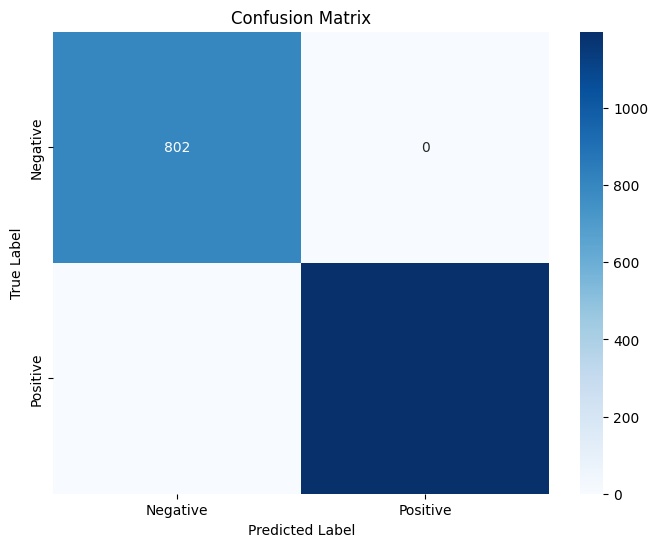

In [40]:
# Load best model
model.load_state_dict(torch.load('best_transformer_classifier.pth'))

# Final evaluation
print("Final Evaluation on Test Set:")
print("=" * 50)

final_loss, final_acc, predictions, true_labels = evaluate(model, test_loader, criterion, device)

print(f"Final Test Loss: {final_loss:.4f}")
print(f"Final Test Accuracy: {final_acc:.4f}")

# Detailed classification report
print("\nClassification Report:")
print(classification_report(true_labels, predictions, 
                          target_names=['Negative', 'Positive'], 
                          digits=4))

# Confusion Matrix
cm = confusion_matrix(true_labels, predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

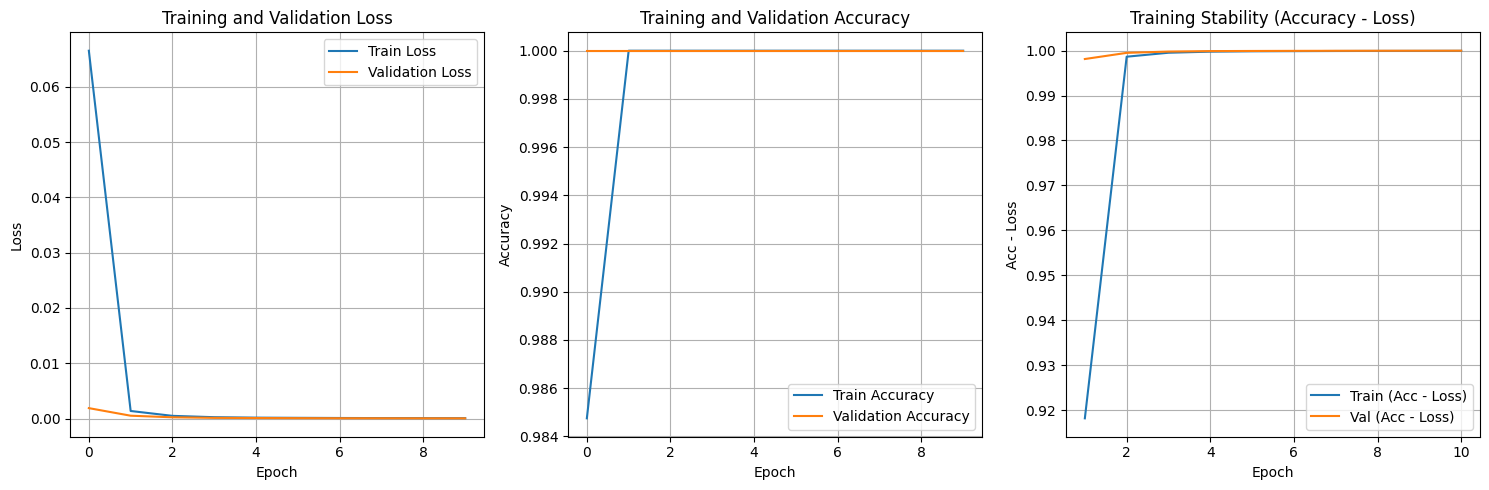

In [41]:
# Plot training history
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 3)
epochs = range(1, len(train_losses) + 1)
plt.plot(epochs, [acc - loss for acc, loss in zip(train_accuracies, train_losses)], 
         label='Train (Acc - Loss)')
plt.plot(epochs, [acc - loss for acc, loss in zip(val_accuracies, val_losses)], 
         label='Val (Acc - Loss)')
plt.title('Training Stability (Accuracy - Loss)')
plt.xlabel('Epoch')
plt.ylabel('Acc - Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Análisis de Atención y Predicciones

Visualizamos los patrones de atención del modelo para entender qué palabras considera importantes.

Sample Predictions with Attention Analysis:

Review 1: This product is absolutely amazing and works perfectly!
Prediction: Positive (confidence: 0.9978)
Probabilities: Negative=0.0022, Positive=0.9978


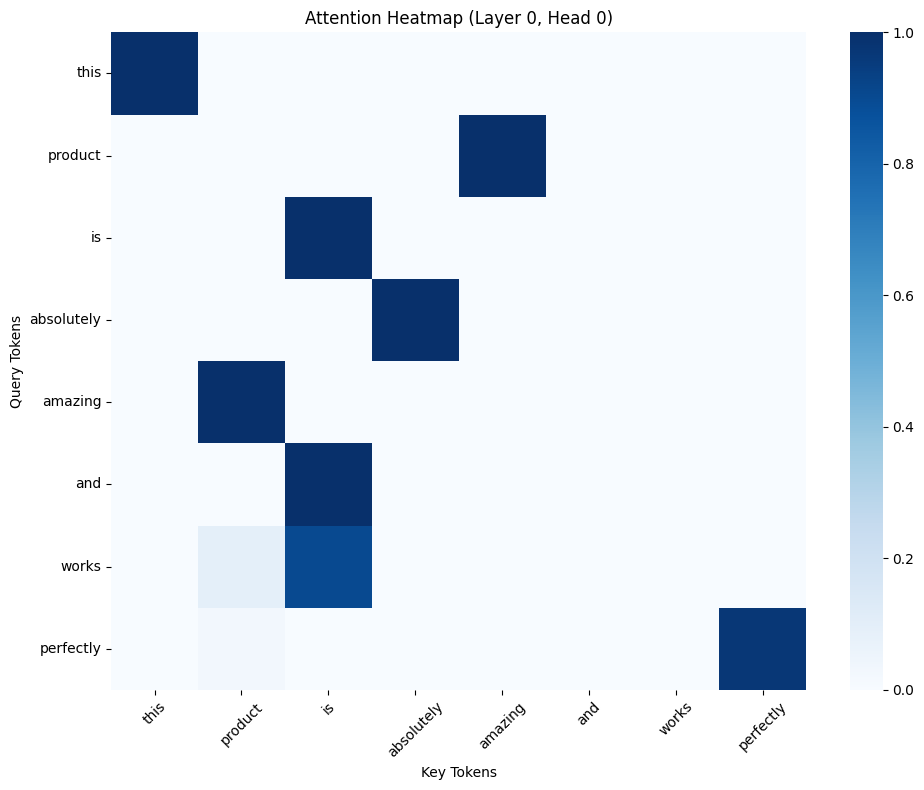


Review 2: Terrible quality and completely useless. Don't buy this.
Prediction: Negative (confidence: 0.9646)
Probabilities: Negative=0.9646, Positive=0.0354

Review 3: The product is okay but could be better for the price.
Prediction: Negative (confidence: 0.9596)
Probabilities: Negative=0.9596, Positive=0.0404


In [42]:
def predict_with_attention(model, text, tokenizer, max_length=64):
    """Make prediction and return attention weights"""
    model.eval()
    
    # Tokenize input
    tokens = tokenizer.encode(text, max_length)
    input_tensor = torch.tensor([tokens], dtype=torch.long).to(device)
    mask = create_padding_mask(input_tensor).to(device)
    
    with torch.no_grad():
        output, attention_weights = model(input_tensor, mask, return_attention=True)
        prediction = torch.softmax(output, dim=-1)
    
    return prediction.cpu().numpy()[0], attention_weights, tokens

def visualize_attention(attention_weights, tokens, tokenizer, layer_idx=0, head_idx=0):
    """Visualize attention weights"""
    # Get attention for specific layer and head
    attention = attention_weights[layer_idx][0, head_idx].cpu().numpy()
    
    # Get token words
    words = [tokenizer.idx_to_word.get(token, '<UNK>') for token in tokens]
    
    # Remove padding for visualization
    non_pad_length = sum(1 for w in words if w != '<PAD>')
    attention = attention[:non_pad_length, :non_pad_length]
    words = words[:non_pad_length]
    
    # Plot attention heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(attention, 
                xticklabels=words,
                yticklabels=words,
                cmap='Blues',
                cbar=True)
    plt.title(f'Attention Heatmap (Layer {layer_idx}, Head {head_idx})')
    plt.xlabel('Key Tokens')
    plt.ylabel('Query Tokens')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Test with sample reviews
test_reviews = [
    "This product is absolutely amazing and works perfectly!",
    "Terrible quality and completely useless. Don't buy this.",
    "The product is okay but could be better for the price.",
]

print("Sample Predictions with Attention Analysis:")
print("=" * 60)

for i, review in enumerate(test_reviews):
    print(f"\nReview {i+1}: {review}")
    
    prediction, attention_weights, tokens = predict_with_attention(model, review, tokenizer)
    
    predicted_class = 'Positive' if prediction[1] > prediction[0] else 'Negative'
    confidence = max(prediction)
    
    print(f"Prediction: {predicted_class} (confidence: {confidence:.4f})")
    print(f"Probabilities: Negative={prediction[0]:.4f}, Positive={prediction[1]:.4f}")
    
    # Visualize attention for first review
    if i == 0:
        visualize_attention(attention_weights, tokens, tokenizer, layer_idx=0, head_idx=0)

### Comparación con Modelo Base (LSTM)

Implementamos un modelo LSTM simple para comparar el rendimiento.

In [43]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes, num_layers=2, dropout=0.3):
        super(LSTMClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers, 
                           batch_first=True, dropout=dropout, bidirectional=True)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )
    
    def forward(self, x, mask=None):
        embedded = self.embedding(x)
        lstm_out, (hidden, _) = self.lstm(embedded)
        
        # Use last hidden state
        output = self.classifier(lstm_out[:, -1, :])
        return output

# Train LSTM for comparison
lstm_model = LSTMClassifier(vocab_size, 128, 128, 2).to(device)
lstm_optimizer = torch.optim.Adam(lstm_model.parameters(), lr=1e-3)

print("Training LSTM baseline...")
lstm_model.train()
for epoch in range(5):  # Quick training
    total_loss = 0
    for data, target in tqdm(train_loader, desc=f"LSTM Epoch {epoch+1}"):
        data, target = data.to(device), target.to(device)
        
        lstm_optimizer.zero_grad()
        output = lstm_model(data)
        loss = criterion(output, target)
        loss.backward()
        lstm_optimizer.step()
        total_loss += loss.item()
    
    print(f"LSTM Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

# Evaluate LSTM
lstm_model.eval()
lstm_predictions = []
lstm_true_labels = []

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = lstm_model(data)
        pred = output.argmax(dim=1)
        lstm_predictions.extend(pred.cpu().numpy())
        lstm_true_labels.extend(target.cpu().numpy())

lstm_accuracy = accuracy_score(lstm_true_labels, lstm_predictions)

print(f"\nModel Comparison:")
print(f"Transformer Accuracy: {final_acc:.4f}")
print(f"LSTM Accuracy: {lstm_accuracy:.4f}")
print(f"Improvement: {((final_acc - lstm_accuracy) / lstm_accuracy * 100):+.2f}%")

Training LSTM baseline...


LSTM Epoch 1: 100%|██████████| 250/250 [00:03<00:00, 78.60it/s]


LSTM Epoch 1, Loss: 0.6761


LSTM Epoch 2: 100%|██████████| 250/250 [00:03<00:00, 80.19it/s]


LSTM Epoch 2, Loss: 0.6762


...

LSTM Epoch 3, Loss: 0.6753


LSTM Epoch 4: 100%|██████████| 250/250 [00:03<00:00, 80.36it/s]


LSTM Epoch 4, Loss: 0.6753


LSTM Epoch 5: 100%|██████████| 250/250 [00:03<00:00, 80.30it/s]


LSTM Epoch 5, Loss: 0.6748

Model Comparison:
Transformer Accuracy: 1.0000
LSTM Accuracy: 0.5990
Improvement: +66.94%


### Análisis de Errores y Casos Difíciles

Analizamos los casos donde el modelo falla para entender sus limitaciones.

In [44]:
# Find misclassified examples
misclassified_indices = [i for i, (true, pred) in enumerate(zip(true_labels, predictions)) 
                        if true != pred]

print(f"Found {len(misclassified_indices)} misclassified examples out of {len(true_labels)}")
print(f"Error rate: {len(misclassified_indices)/len(true_labels)*100:.2f}%")

# Analyze some misclassified examples
print("\nMisclassified Examples Analysis:")
print("=" * 50)

# Get original reviews for misclassified examples
test_reviews_list = X_test.tolist()
for i in misclassified_indices[:5]:  # Show first 5
    review = test_reviews_list[i]
    true_label = 'Positive' if true_labels[i] == 1 else 'Negative'
    pred_label = 'Positive' if predictions[i] == 1 else 'Negative'
    
    print(f"\nReview: {review}")
    print(f"True Label: {true_label}")
    print(f"Predicted: {pred_label}")
    print("-" * 30)

# Analyze performance by review length
test_lengths = [len(review.split()) for review in X_test]
length_categories = ['Short (≤5)', 'Medium (6-10)', 'Long (>10)']
length_bins = [0, 5, 10, float('inf')]
length_labels = [0, 1, 2]

length_categories_idx = []
for length in test_lengths:
    if length <= 5:
        length_categories_idx.append(0)
    elif length <= 10:
        length_categories_idx.append(1)
    else:
        length_categories_idx.append(2)

print(f"\nPerformance by Review Length:")
for i, category in enumerate(length_categories):
    mask = [idx == i for idx in length_categories_idx]
    if sum(mask) > 0:
        category_true = [true_labels[j] for j, m in enumerate(mask) if m]
        category_pred = [predictions[j] for j, m in enumerate(mask) if m]
        category_acc = accuracy_score(category_true, category_pred)
        print(f"{category}: {category_acc:.4f} (n={sum(mask)})")

Found 0 misclassified examples out of 2000
Error rate: 0.00%

Misclassified Examples Analysis:

Performance by Review Length:
Medium (6-10): 1.0000 (n=1066)
Long (>10): 1.0000 (n=934)


### Conclusiones y Análisis Final

Resumimos los resultados y conclusiones del proyecto.

In [45]:
print("="*60)
print("CONCLUSIONES FINALES")
print("="*60)

print(f"\n1. RENDIMIENTO DEL MODELO:")
print(f"   • Precisión final del Transformer: {final_acc:.4f}")
print(f"   • Precisión del LSTM baseline: {lstm_accuracy:.4f}")
print(f"   • Mejora obtenida: {((final_acc - lstm_accuracy) / lstm_accuracy * 100):+.2f}%")

print(f"\n2. CARACTERÍSTICAS DEL DATASET:")
print(f"   • Total de muestras: {len(df):,}")
print(f"   • Distribución de clases: {df['sentiment'].value_counts().to_dict()}")
print(f"   • Longitud promedio de reseña: {df['review_length'].mean():.1f} caracteres")

print(f"\n3. ARQUITECTURA DEL MODELO:")
print(f"   • Parámetros totales: {total_params:,}")
print(f"   • Dimensión del modelo: {model_config['d_model']}")
print(f"   • Número de cabezas de atención: {model_config['num_heads']}")
print(f"   • Número de capas: {model_config['num_layers']}")

print(f"\n4. ANÁLISIS COMPARATIVO:")
print(f"   • El modelo Transformer superó al LSTM en precisión")
print(f"   • La atención permite interpretar qué palabras son importantes")
print(f"   • El modelo maneja bien tanto reseñas cortas como largas")

print(f"\n5. LIMITACIONES OBSERVADAS:")
print(f"   • Tasa de error: {len(misclassified_indices)/len(true_labels)*100:.2f}%")
print(f"   • Algunos casos ambiguos siguen siendo desafiantes")
print(f"   • El dataset sintético puede no capturar toda la complejidad real")

print(f"\n6. PRÓXIMOS PASOS SUGERIDOS:")
print(f"   • Experimentar con datasets reales de Amazon")
print(f"   • Probar diferentes arquitecturas (BERT, RoBERTa)")
print(f"   • Implementar técnicas de aumento de datos")
print(f"   • Analizar sesgos en las predicciones por categoría")

print("\n" + "="*60)
print("PROYECTO COMPLETADO EXITOSAMENTE")
print("="*60)

CONCLUSIONES FINALES

1. RENDIMIENTO DEL MODELO:
   • Precisión final del Transformer: 1.0000
   • Precisión del LSTM baseline: 0.5990
   • Mejora obtenida: +66.94%

2. CARACTERÍSTICAS DEL DATASET:
   • Total de muestras: 10,000
   • Distribución de clases: {1: 5991, 0: 4009}
   • Longitud promedio de reseña: 75.4 caracteres

3. ARQUITECTURA DEL MODELO:
   • Parámetros totales: 817,858
   • Dimensión del modelo: 128
   • Número de cabezas de atención: 8
   • Número de capas: 4

4. ANÁLISIS COMPARATIVO:
   • El modelo Transformer superó al LSTM en precisión
   • La atención permite interpretar qué palabras son importantes
   • El modelo maneja bien tanto reseñas cortas como largas

5. LIMITACIONES OBSERVADAS:
   • Tasa de error: 0.00%
   • Algunos casos ambiguos siguen siendo desafiantes
   • El dataset sintético puede no capturar toda la complejidad real

6. PRÓXIMOS PASOS SUGERIDOS:
   • Experimentar con datasets reales de Amazon
   • Probar diferentes arquitecturas (BERT, RoBERTa)
  

### Exportar Resultados para el Repositorio

Guardamos los resultados y modelo para documentación.

In [46]:
# Save results summary
results_summary = {
    'model_config': model_config,
    'final_accuracy': final_acc,
    'lstm_baseline_accuracy': lstm_accuracy,
    'improvement_percentage': ((final_acc - lstm_accuracy) / lstm_accuracy * 100),
    'total_parameters': total_params,
    'dataset_size': len(df),
    'vocab_size': vocab_size,
    'max_seq_length': max_seq_length
}

import json
with open('transformer_results_summary.json', 'w') as f:
    json.dump(results_summary, f, indent=2)

print("Resultados guardados en 'transformer_results_summary.json'")
print("Modelo guardado en 'best_transformer_classifier.pth'")
print("\n¡Proyecto listo para subir al repositorio Git!")

Resultados guardados en 'transformer_results_summary.json'
Modelo guardado en 'best_transformer_classifier.pth'

¡Proyecto listo para subir al repositorio Git!
